In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_selfies_transformer=True)
df = qm9.load()

2026-04-17 12:01:30.072 | INFO     | src.datasets:load:493 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-17 12:01:30.366 | INFO     | src.datasets:_sample_qm9_df:685 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-17 12:01:30.366 | INFO     | src.datasets:_add_requested_descriptors:126 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-17 12:01:30.367 | INFO     | src.features:compute_selfies_transformer:93 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.1 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
2026-04-17 12:02:17.977 | INFO     | src.features:compute_selfies_transformer:132 - Reducing dimensions from 768 to 32 using PCA...
2026-04-17 12:02:18.342 | INFO     | src.datasets:_add_requested_descriptors:149 - Added descriptor column(s): ['selfies_transformer']


In [4]:
len(df['selfies_transformer'].to_list()[0])

32

In [5]:
molecules = qm9.get_molecules()

2026-04-17 12:02:44.560 | SUCCESS  | src.datasets:get_molecules:1170 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


In [6]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="transformer",
    dist_type="euclidean",
    force_calculate=True
)

2026-04-17 12:02:44.677 | INFO     | src.datasets:get_distance_matrix:1001 - Calculating distance matrix for selfies_transformer using euclidean distance.
2026-04-17 12:02:45.053 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/QM9/dist_selfies_transformer_euclidean.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:05<00:00,  1.88it/s]


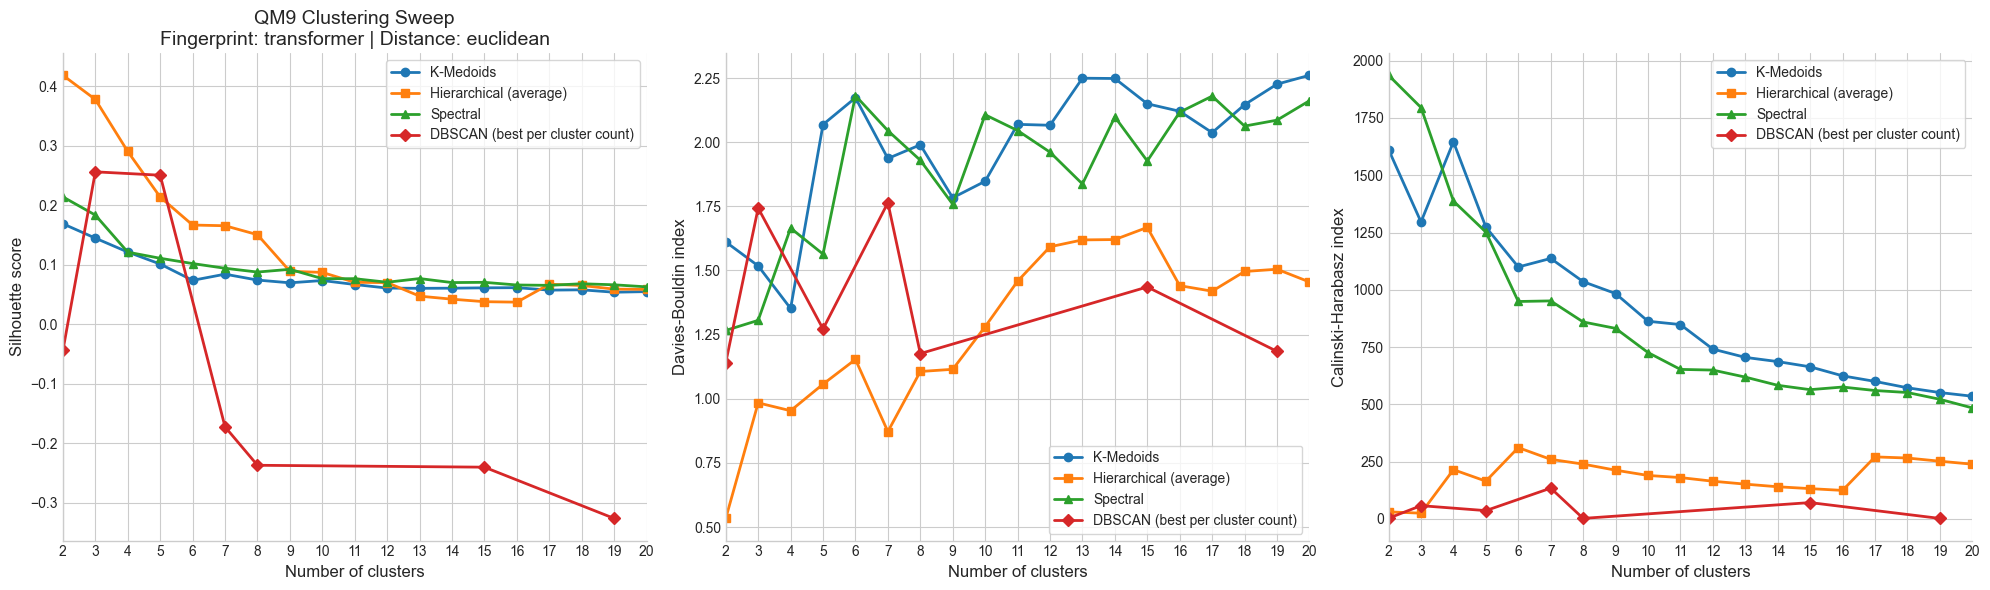

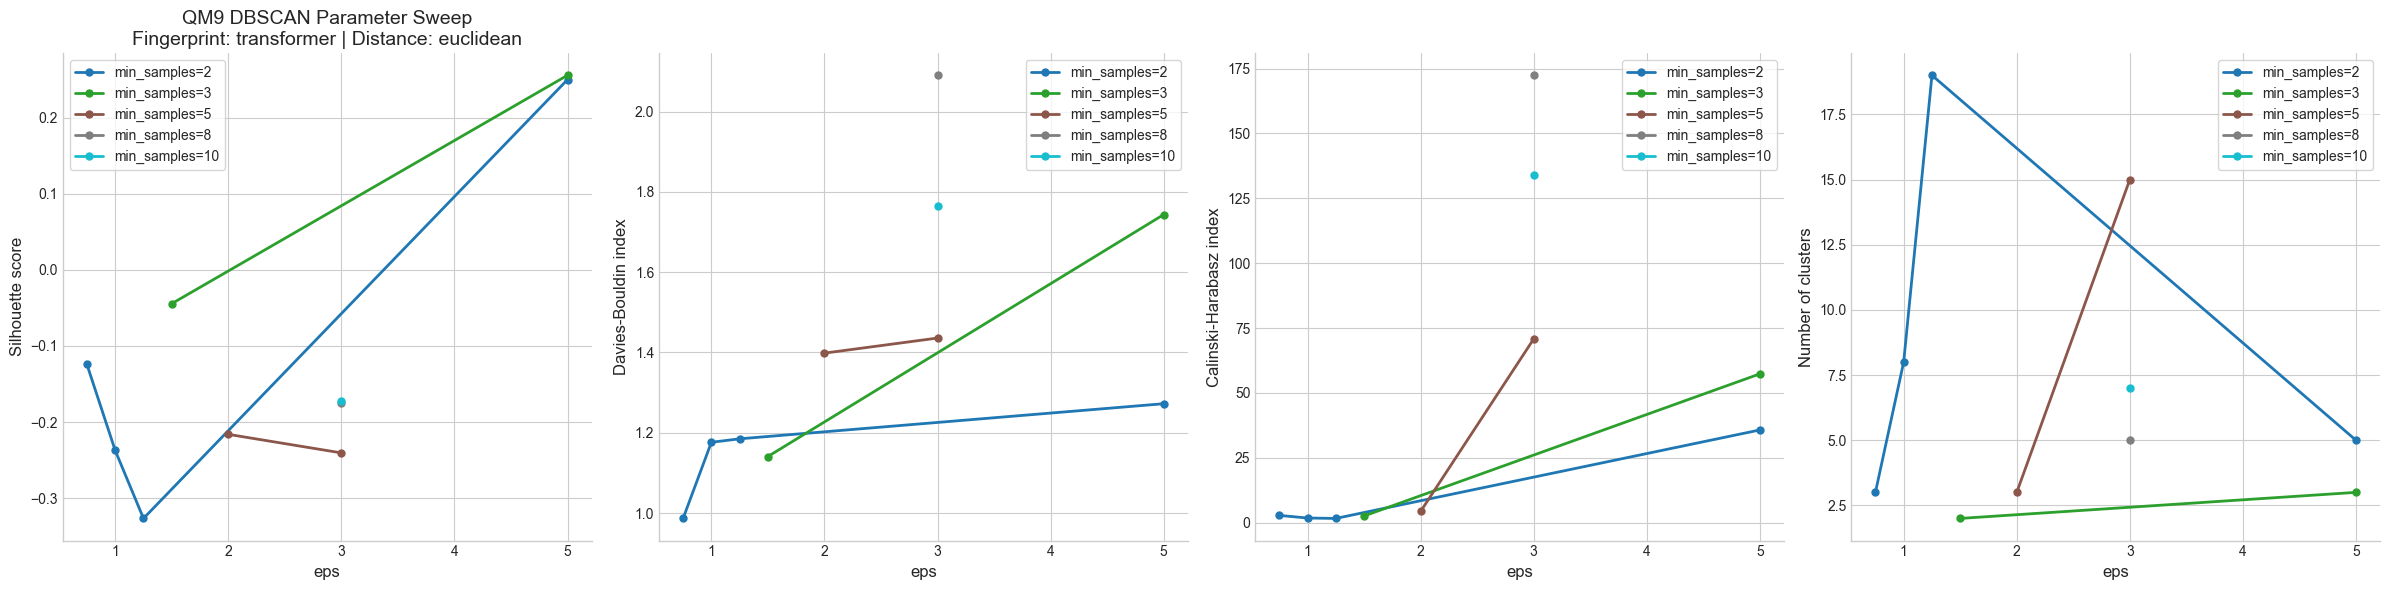

2026-04-17 12:03:54.594 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:840 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/transformer/clustering_sweep_2_to_20_clusters.png
2026-04-17 12:03:54.595 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:842 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/transformer/dbscan_parameter_sweep.png
2026-04-17 12:03:54.595 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved clustering sweep results to figures/qm9/clustering/euclidean/transformer/clustering_sweep_2_to_20_clusters.json


In [8]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [9]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4966), np.int64(4967)), (np.int64(3770), np.int64(3832)), (np.int64(4958), np.int64(4965)), (np.int64(3986), np.int64(3987)), (np.int64(3775), np.int64(4443)), (np.int64(4590), np.int64(4591)), (np.int64(3793), np.int64(4409)), (np.int64(3524), np.int64(3526)), (np.int64(1205), np.int64(1206)), (np.int64(2282), np.int64(3790))]


In [10]:
print(mols[0])

(Atoms(symbols='N2HFC2HC2NC', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='CNHNCFCHC2N', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [12]:
plot_molecules_with_py3dmol(mols[2])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

In [12]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1, 2]), array([1206, 3370,  424]))


In [13]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [15]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-17 12:07:38.778 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_hierarchical_projection.png


{'coords': array([[ 13.07138607, -36.31214043],
        [ 68.20321183,  64.26232225],
        [ 82.20655328, -34.48686014],
        ...,
        [ 15.42390224,  31.86815376],
        [ 23.76446379,   0.96770334],
        [  2.67608941, -37.94235039]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'hierarchical'}

In [14]:
average_numeric_by_cluster(df, "labels_hier")

shape: (3, 59)
┌─────────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────────┬──────────────┬─────────────┐
│ labels_hier ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_ring

# KMedoids

In [35]:
model_km = KMedoids(n_clusters=7, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2, 3, 4, 5, 6], dtype=uint64), array([995, 352, 786, 690, 974, 794, 409]))


In [36]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [37]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-15 16:53:30.634 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_kmedoids_projection.png


{'coords': array([[ 13.09643095, -36.29556991],
        [ 68.14868767,  64.24176195],
        [ 82.11265034, -34.54765941],
        ...,
        [ 15.30567121,  31.8077565 ],
        [ 23.73907735,   0.95200924],
        [  2.58198632, -38.00463082]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'kmedoids'}

In [38]:
average_numeric_by_cluster(df, "labels_km")

labels_km,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,995,2.163168,18.028141,122.819095,-0.107538,34.454271,0.893392,12.807423,8.820101,2.431156,0.01608,2.134531,1.630151,0.050908,0.104775,0.844317,1.062312,1.922613,6.78593,0.335678,0.669347,5.561809,6.036181,39.105528,1.274662,0.0,0.510553,0.0,0.069347,0.054271,0.001005,0.031156,0.102513,0.617085,0.0,2.253266,2.515559,74.129075,-6.555165,0.636385,7.191586,1068.350173,4.071839,-11111.058651,-11110.843691,-11110.817997,-11111.941307,30.496796,-76.150087,-76.629939,-77.067595,-70.845488,3.122426,1.568384,1.281326,0.342714,98.190955,1.60804,0.201005
1,352,1.799639,13.505682,121.349432,-0.03125,63.284091,0.625747,13.026502,8.698864,1.142045,0.764205,2.020186,1.53125,0.058597,0.744054,0.197348,1.085227,3.113636,5.252841,0.309659,3.3125,0.946023,6.139205,24.5,1.266947,0.008523,0.136364,0.144886,0.261364,0.170455,0.002841,0.051136,0.082386,0.289773,0.017045,4.130682,3.280733,67.527159,-6.592662,-1.20793,5.384739,1067.157442,2.666177,-11957.228437,-11957.027413,-11957.001776,-11958.106123,27.010145,-60.576547,-60.896075,-61.217442,-56.566708,4.037706,1.55721,1.107809,0.116477,27.272727,65.625,7.102273
2,786,2.201208,18.802799,123.89313,-0.080153,32.068702,0.86927,12.843548,8.872774,1.832061,0.013995,2.076346,2.114504,0.048521,0.147249,0.80423,0.830789,1.709924,7.031807,0.314249,0.970738,5.370229,6.089059,41.496183,1.264862,0.003817,0.181934,0.001272,0.136132,0.125954,0.003817,0.044529,0.225191,0.445293,0.0,2.217557,2.960648,76.770204,-6.566263,0.181125,6.747378,1171.936263,4.28226,-11071.929751,-11071.694356,-11071.668707,-11072.840721,32.420799,-79.108177,-79.59752,-80.055095,-73.601878,3.001589,1.403703,1.131487,0.0,96.564885,1.399491,2.035623
3,690,2.08307,18.830435,124.205797,0.304348,37.737681,0.831473,12.894638,8.84058,0.976812,0.269565,1.998109,2.968116,0.030987,0.329123,0.63989,0.775362,1.994203,6.836232,0.207246,1.994203,4.044928,6.563768,39.392754,1.251487,0.007246,0.153623,0.024638,0.168116,0.368116,0.005797,0.049275,0.181159,0.372464,0.008696,2.594203,3.070205,77.403812,-6.422061,0.052447,6.474527,1320.655386,4.290816,-11279.203571,-11278.952468,-11278.92674,-11280.147168,33.392961,-79.117174,-79.591788,-80.050075,-73.634118,3.418572,1.220753,0.963651,0.0,53.768116,26.956522,19.275362
4,974,2.124771,20.674538,123.536961,0.598563,24.853183,0.947283,12.820282,8.772074,1.300821,0.008214,2.024091,3.277207,0.068112,0.082093,0.849795,0.665298,1.553388,6.727926,0.50616,0.583162,5.99384,6.789528,44.058522,1.252396,0.0,0.513347,0.0,0.034908,0.0154,0.0,0.01232,0.062628,0.704312,0.0,1.688912,1.982222,80.088532,-6.684223,1.092185,7.776408,1342.167355,4.878038,-10841.016236,-10840.761594,-10840.73593,-10841.952647,34.796994,-84.834108,-85.376282,-85.881992,-78.828669,3.361012,1.231296,1.017841,0.010267,83.162218,0.821355,16.016427
5,794,1.88622,15.90806,121.347607,-0.010076,49.599496,0.771962,12.911496,8.690176,0.876574,0.516373,1.984923,2.498741,0.132294,0.451318,0.416388,1.139798,2.70529,5.498741,0.823678,2.357683,2.280856,6.653652,30.151134,1.252549,0.005038,0.261965,0.123426,0.283375,0.172544,0.0,0.062972,0.088161,0.381612,0.003778,3.22796,3.114632,72.15607,-6.426414,-0.336297,6.090097,124

# Spectral

In [16]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [17]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [33]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-17 14:04:10.697 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_spectral_projection.png


{'coords': array([[ 13.07138607, -36.31214043],
        [ 68.20321183,  64.26232225],
        [ 82.20655328, -34.48686014],
        ...,
        [ 15.42390224,  31.86815376],
        [ 23.76446379,   0.96770334],
        [  2.67608941, -37.94235039]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'spectral'}

In [34]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 61)
┌─────────────────┬───────┬─────────────────────┬───────────┬────────────┬────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_spectral ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp   ┆ tpsa    ┆ election_affinity ┆ ionization_energ

# DBSCAN 

In [31]:
model_db = DBSCAN(
    eps=5,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([-1,  0,  1,  2]), array([  21, 4973,    3,    3]))


In [32]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [35]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-17 14:09:19.939 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_dbscan_projection.png


{'coords': array([[ 13.07138607, -36.31214043],
        [ 68.20321183,  64.26232225],
        [ 82.20655328, -34.48686014],
        ...,
        [ 15.42390224,  31.86815376],
        [ 23.76446379,   0.96770334],
        [  2.67608941, -37.94235039]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'dbscan'}

In [36]:
average_numeric_by_cluster(df, "labels_db")

shape: (4, 61)
┌───────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬─────────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_db ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionization_energies 

# KMeans on Raw Embeddings


In [ ]:
X_raw = np.array(df["selfies_transformer"].to_list(), dtype=np.float32)
kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_raw)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)


In [ ]:
average_numeric_by_cluster(df, "labels_kmeans_raw")
